# F1 pit stop Kaggle Competition

## Import datasets and libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

In [179]:
train = pd.read_csv("data/train.csv", index_col=0)
test = pd.read_csv("data/test.csv", index_col=0)
sample_submission = pd.read_csv("data/sample_submission.csv", index_col=0)

print(train.head(5))
print(test.head(5))
print(sample_submission.head(5))


   Driver Compound  ... Position_Change  PitNextLap
id                  ...                            
0    D109     HARD  ...             5.0         1.0
1    D086     HARD  ...            -3.0         0.0
2     ZON     HARD  ...             3.0         1.0
3     SPE   MEDIUM  ...             0.0         0.0
4    D019     HARD  ...             3.0         0.0

[5 rows x 15 columns]
       Driver Compound  ... RaceProgress  Position_Change
id                      ...                              
439140   D119   MEDIUM  ...     0.403846              0.0
439141    VER   MEDIUM  ...     0.413793              0.0
439142   D270   MEDIUM  ...     0.461538              0.0
439143   D112     SOFT  ...     0.077922              1.0
439144    AND     HARD  ...     0.722222              7.0

[5 rows x 14 columns]
        PitNextLap
id                
439140           0
439141           0
439142           0
439143           0
439144           0


## Exploring the Dataset

Here we have a description of the meaning of fthe variables  
Year – Season of the race, Race – Grand Prix name, Driver – Driver code,   
LapNumber – Lap index within the race, Position – Driver’s position on that lap,   
LapTime (s) – Lap time in seconds, Stint – Tire stint number, TyreLife – Number of laps on current tire,  
Compound – Tire compound, LapTime_Delta – Change in lap time from previous lap,  
Cumulative_Degradation – Accumulated tire performance drop,   
Position_Change – Position gain/loss compared to previous lap,   
RaceProgress – Fraction of race completed (0 → 1),  
PitStop – Whether the driver pitted on that lap (0/1),  
PitNextLap – Target variable: whether the driver will pit next lap (0/1)

In [5]:
print(train.info(), test.info())


<class 'pandas.core.frame.DataFrame'>
Index: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap              4

In [6]:
train.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [7]:
# for the lap time variables we have a very high value for the max,
# it could be some sort of outlier (a lap of 40 minutes is not normal)
print(train['LapTime (s)'].describe())
print(train.loc[train['LapTime (s)'] > 300, 'PitNextLap'].value_counts())
print(train.loc[train['LapTime (s)'] > 300, 'PitStop'].value_counts())
# there are some units with some strange lap times and they did stop on that or the next lap


count    439140.000000
mean         90.948735
std          19.772769
min          67.694000
25%          82.621000
50%          90.521000
75%          98.471000
max        2507.607000
Name: LapTime (s), dtype: float64
PitNextLap
0.0    20
Name: count, dtype: int64
PitStop
0    17
1     3
Name: count, dtype: int64


In [8]:
# let's explore the data a bit more
print(train['PitNextLap'].value_counts())
# check for missing values in the train dataset
print('Missing values in train dataset:', sum(train.isnull().sum()))
# there are no missing values at all
print('Missing values in test dataset:', sum(test.isnull().sum()))


PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64
Missing values in train dataset: 0
Missing values in test dataset: 0


In [9]:
# give a look to the categorical variables
print(train.select_dtypes(include='object').nunique())
#887 drivers are too many, years is between 2022 and 2025 and we should have 20 drivers each year.
print(train.Driver.unique()[:50]) # many drivers have a code as D000
# Now I want to check how many drivers are with name and no code, and if the code in the test set
# are the same as in the train set
# To split the two category I will use the fact that the code is always 4 characters long
code_names = [code for code in train.Driver.unique() if len(code) == 4]
code_names.sort()
print(f"Number of drivers with codes: {len(code_names)}")
print(f"Number of drivers without codes: {train.Driver.nunique() - len(code_names)}")
print(code_names[:10]) # the first 10 codes
print(code_names[-1:])
# we have 756 driver with code
train.groupby(['Year', 'Race', 'Driver']).LapNumber.count()
# from this table we can see that in each race we actually have only few laps for each driver.

Driver      887
Compound      5
Race         26
dtype: int64
['D109' 'D086' 'ZON' 'SPE' 'D019' 'D012' 'D104' 'D082' 'BEL' 'YAM' 'MAS'
 'D010' 'D063' 'D196' 'D132' 'D047' 'PRO' 'D066' 'DRA' 'PEA' 'HAD' 'HUL'
 'COU' 'D036' 'D205' 'BER' 'VIL' 'GUT' 'TUR' 'D089' 'D055' 'D189' 'D071'
 'DAM' 'D144' 'D384' 'D263' 'D117' 'D120' 'D054' 'D184' 'D214' 'IDE'
 'D216' 'D101' 'D160' 'WIL' 'CAR' 'D251' 'D106']
Number of drivers with codes: 756
Number of drivers without codes: 131
['D001', 'D002', 'D003', 'D004', 'D005', 'D006', 'D007', 'D008', 'D009', 'D010']
['D756']


Year  Race                      Driver
2022  Abu Dhabi Grand Prix      ALB        3
                                ALO        6
                                ANT        1
                                GAS        3
                                HAM        2
                                          ..
2025  United States Grand Prix  WIL       22
                                WUR       21
                                YAM       19
                                ZHO        3
                                ZON       15
Name: LapNumber, Length: 40869, dtype: int64

In [10]:
train.loc[(train['Year'] == 2022) & (train['Race'] == 'Australian Grand Prix') & (train['Driver'] == 'HAM'), ['Driver', 'Year', 'Race', 'LapNumber', 'Stint', 'PitStop', 'PitNextLap']]

,Driver,Year,Race,LapNumber,Stint,PitStop,PitNextLap
id,,,,,,,
102977,HAM,2022,Australian Grand Prix,11,1,1,0.0
138405,HAM,2022,Australian Grand Prix,33,2,0,0.0
151242,HAM,2022,Australian Grand Prix,9,1,0,0.0
172066,HAM,2022,Australian Grand Prix,19,1,0,0.0
211890,HAM,2022,Australian Grand Prix,12,1,1,1.0
259032,HAM,2022,Australian Grand Prix,8,1,0,0.0
289746,HAM,2022,Australian Grand Prix,4,1,0,1.0
350515,HAM,2022,Australian Grand Prix,40,2,0,1.0
351834,HAM,2022,Australian Grand Prix,17,1,0,0.0


There is clearly some problem with this data, they cannot be realistic, because from this table
we can see that he has 5 Pit Next Lap, 2 Pit Stops and only 2 stint (1 Pit stop), so 
probably this data have been generated as independent, so we should treat them as independent 
if we want to use this dataset, or we should use the original dataset from which the data are generated. 

In [11]:
# Let's see if the kind of problem arises also when we explore the test dataset
print(test.loc[(test['Year'] == 2022) & (test['Race'] == 'Australian Grand Prix') & (test['Driver'] == 'HAM'), ['Driver', 'Year', 'Race', 'LapNumber', 'Stint', 'PitStop']])
print(test.loc[(test['Year'] == 2022) & (test['Race'] == 'Australian Grand Prix') & (test['Driver'] == 'ALO'), ['Driver', 'Year', 'Race', 'LapNumber', 'Stint', 'PitStop']])
print(test.loc[(test['Year'] == 2022) & (test['Race'] == 'Australian Grand Prix') & (test['Driver'] == 'ALB'), ['Driver', 'Year', 'Race', 'LapNumber', 'Stint', 'PitStop']])
# we can see a similar issue, ALO from lap 47 to 49 increases the stint from 1 to 4
# ALB at lap 15 Pit Stop is 1, but at lap 16 PitStop is 0, and at lap 18 his stint is still 1


       Driver  Year                   Race  LapNumber  Stint  PitStop
id                                                                   
446334    HAM  2022  Australian Grand Prix         30      1        0
449698    HAM  2022  Australian Grand Prix         48      4        0
472300    HAM  2022  Australian Grand Prix         20      1        1
552430    HAM  2022  Australian Grand Prix         36      4        0
566328    HAM  2022  Australian Grand Prix         14      1        0
567505    HAM  2022  Australian Grand Prix         27      1        0
573591    HAM  2022  Australian Grand Prix         32      1        1
       Driver  Year                   Race  LapNumber  Stint  PitStop
id                                                                   
493461    ALO  2022  Australian Grand Prix         49      4        0
527370    ALO  2022  Australian Grand Prix         63      2        0
584065    ALO  2022  Australian Grand Prix         47      1        0
       Driver  Year 

[Text(0.5, 1.0, 'Stint vs LapNumber in Australian Grand Prix 2022')]

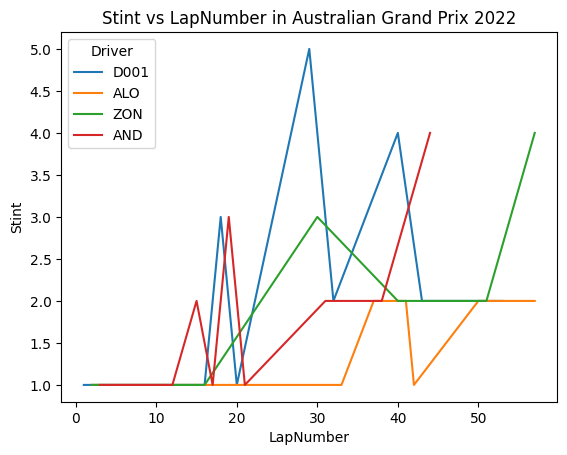

In [12]:
Australia_2022 = train[(train['Year'] == 2022) & (train['Race'] == 'Australian Grand Prix') & (train['Driver'].isin(['ZON', 'ALO', 'AND', 'D001']))]
sns.lineplot(data=Australia_2022, x='LapNumber', y='Stint', hue='Driver').set(title='Stint vs LapNumber in Australian Grand Prix 2022')
# Australia_2022.sort_values(by=['Driver', 'LapNumber'])
# the variable Stint should not decrease, but we can see that for some drivers it does. 
# this means that the data is not consistent, so we should be aware that the record of a driver
# in a race could be not related and we shoul treat them as independent records.


[Text(0.5, 1.0, 'Stint vs LapNumber in Australian Grand Prix 2022')]

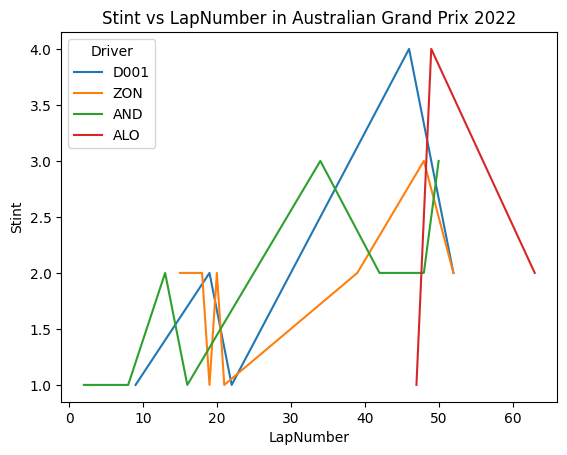

In [13]:
Australia_2022_test = test[(test['Year'] == 2022) & (test['Race'] == 'Australian Grand Prix') & (test['Driver'].isin(['ZON', 'ALO', 'AND', 'D001']))]
sns.lineplot(data=Australia_2022_test, x='LapNumber', y='Stint', hue='Driver').set(title='Stint vs LapNumber in Australian Grand Prix 2022')
# the same problem arises in the test set

In [14]:
# now give a look to the driver with a code, and see if they have more than one record in the same race
print(train.groupby(['Year', 'Race', 'Driver']).count().reset_index().loc[train.groupby(['Year', 'Race', 'Driver']).count().reset_index()['Driver'].isin(code_names)])
# we have that for some code names we have only one record, and for some others we have more than one record.
train.loc[(train['Year'] == 2022) & (train['Race'] == 'Australian Grand Prix') & (train['Driver'] == 'D001'), ['Driver', 'Year', 'Race', 'LapNumber', 'Stint', 'PitStop', 'PitNextLap']]. sort_values(by=['LapNumber']).head(10)

       Year                      Race  ... Position_Change  PitNextLap
45     2022     Australian Grand Prix  ...              22          22
46     2022     Australian Grand Prix  ...              24          24
47     2022     Australian Grand Prix  ...              14          14
48     2022     Australian Grand Prix  ...              15          15
49     2022     Australian Grand Prix  ...              21          21
...     ...                       ...  ...             ...         ...
40764  2025  United States Grand Prix  ...               1           1
40765  2025  United States Grand Prix  ...               1           1
40766  2025  United States Grand Prix  ...               1           1
40767  2025  United States Grand Prix  ...               1           1
40768  2025  United States Grand Prix  ...               1           1

[28823 rows x 15 columns]


,Driver,Year,Race,LapNumber,Stint,PitStop,PitNextLap
id,,,,,,,
119815,D001,2022,Australian Grand Prix,1,1,0,0.0
285860,D001,2022,Australian Grand Prix,2,1,0,0.0
58283,D001,2022,Australian Grand Prix,3,1,0,0.0
277967,D001,2022,Australian Grand Prix,4,1,1,0.0
248175,D001,2022,Australian Grand Prix,5,1,0,0.0
145735,D001,2022,Australian Grand Prix,6,1,0,0.0
62704,D001,2022,Australian Grand Prix,7,1,0,0.0
114808,D001,2022,Australian Grand Prix,11,1,0,0.0
378120,D001,2022,Australian Grand Prix,12,1,0,0.0


In [15]:
print(train.Race.unique()) # we see that there are data regarding the Pre-season testing
# let's check if this data are also in the test set otherwise it is not worth to use them for training
print(train.Race.unique()[train.Race.unique()=='Pre-Season Testing'])
print(test.Race.unique()[test.Race.unique()=='Pre-Season Testing'])
# we have the pre season data also in the test set, so we will keep them.

['Canadian Grand Prix' 'Dutch Grand Prix' 'Austrian Grand Prix'
 'Pre-Season Testing' 'Azerbaijan Grand Prix' 'Saudi Arabian Grand Prix'
 'Belgian Grand Prix' 'United States Grand Prix' 'Italian Grand Prix'
 'Hungarian Grand Prix' 'Japanese Grand Prix' 'São Paulo Grand Prix'
 'Bahrain Grand Prix' 'Las Vegas Grand Prix' 'Monaco Grand Prix'
 'British Grand Prix' 'Australian Grand Prix' 'Spanish Grand Prix'
 'Miami Grand Prix' 'French Grand Prix' 'Abu Dhabi Grand Prix'
 'Chinese Grand Prix' 'Mexico City Grand Prix' 'Emilia Romagna Grand Prix'
 'Singapore Grand Prix' 'Qatar Grand Prix']
['Pre-Season Testing']
['Pre-Season Testing']


In [16]:
print(train.Compound.value_counts(), test.Compound.value_counts())

Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64 Compound
MEDIUM          90897
HARD            72677
SOFT            16615
INTERMEDIATE     7408
WET               568
Name: count, dtype: int64


At this point we have notice that our dataset is not like we expected.  
So we can prooced with our dataset considering the issue we have observed or try to build a model
using the data of the original competition that has the complete records.

## Preprocess 

In this section I will check that our variables can be used for training the model and then preprocess them to be able to use them correctly for the estimation.

In [ ]:
print((train.Year.unique(),test.Year.unique()))
# I will consider Year as a categorical variables too

(array([2022, 2025, 2023, 2024], dtype=int64), array([2023, 2024, 2025, 2022], dtype=int64))


'id\n0         2022\n1         2025\n2         2022\n3         2023\n4         2022\n          ... \n439135    2023\n439136    2023\n439137    2023\n439138    2023\n439139    2023\nName: Year, Length: 439140, dtype: int64'

In [89]:
# I check that the the values of the categorical variables are the same for the train and test set,
# otherwise we can't use those variables for training the model. 
categorical_vars = [col for col in train.columns if train[col].dtype == 'object']+['Year']
print(categorical_vars)
train_cat_values = {var: set(train[var].unique()) for var in categorical_vars}
test_cat_values = {var: set(test[var].unique()) for var in categorical_vars}
for var in categorical_vars:
    for val in test_cat_values[var]:
        if val not in train_cat_values[var]:
            print(f"Value '{val}' in test set for variable '{var}' is not present in train set.")
# all values of the categorical variables in test set are also in the training set, so we can use those variables for training the model.


['Driver', 'Compound', 'Race', 'Year']


Now I will remove the driver varible and split the train dataset in two parts: one for training and the other for validation. In this way I can preprocess the training set without using the validation set.   

In [91]:
from sklearn.model_selection import train_test_split
X = train.copy()
y = train['PitNextLap']
X.drop(columns=['PitNextLap', 'Driver'], inplace=True)
print(X.columns)
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.4, random_state=42)

Index(['Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife',
       'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change'],
      dtype='object')


In [92]:
print(train_X.Compound.unique())

['INTERMEDIATE' 'MEDIUM' 'HARD' 'SOFT' 'WET']


At this point we have only 3 categorical variables to encode, **Year**, **Race** (clearly not ordered), **Compound** instead has 5 levels that could be split in 2 groups of ordered values: Wet, Intermidiate (for wet condition) and Hard, Medium, Soft (for dry condition), se we could prepare 2 different encodings, one using an ordered encoding and the other with the one hot encoding

In [97]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
 
# start by using for both the OH encoder
train_X.Year = train_X.Year.astype(str)
val_X.Year = val_X.Year.astype(str)
cat_vars= [var for var in train_X.select_dtypes(include='object').columns]
categories = [train_X[var].unique() for var in cat_vars]

OH_encoder = OneHotEncoder(drop=None, sparse_output=False, categories=categories)
OH_train_var = pd.DataFrame(OH_encoder.fit_transform(train_X[cat_vars]))
OH_val_var = pd.DataFrame(OH_encoder.transform(val_X[cat_vars]))

OH_train_var.index = train_X.index
OH_val_var.index = val_X.index

num_var_train = train_X.drop(columns=cat_vars)
num_var_val = val_X.drop(columns=cat_vars)

OH_train_X = pd.concat([num_var_train, OH_train_var], axis=1)
OH_val_X = pd.concat([num_var_val, OH_val_var], axis=1)

OH_train_X.columns = num_var_train.columns.tolist() + list(categories[0])+list(categories[1])+list(categories[2])
OH_val_X.columns = num_var_val.columns.tolist() + list(categories[0])+list(categories[1])+list(categories[2])

OH_train_X.head()

,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,INTERMEDIATE,MEDIUM,HARD,SOFT,WET,Canadian Grand Prix,Italian Grand Prix,Monaco Grand Prix,Las Vegas Grand Prix,Emilia Romagna Grand Prix,Azerbaijan Grand Prix,Spanish Grand Prix,Miami Grand Prix,Dutch Grand Prix,Pre-Season Testing,British Grand Prix,Austrian Grand Prix,Japanese Grand Prix,Saudi Arabian Grand Prix,Hungarian Grand Prix,Singapore Grand Prix,Mexico City Grand Prix,United States Grand Prix,Abu Dhabi Grand Prix,Qatar Grand Prix,Bahrain Grand Prix,Chinese Grand Prix,Australian Grand Prix,São Paulo Grand Prix,French Grand Prix,Belgian Grand Prix,2024,2023,2025,2022
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10132,0,12,1,12.0,8,89.834,-6.726,7.874,0.155844,8.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
47355,0,18,1,18.0,1,85.259,0.059,-5.872,0.352941,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
366839,0,25,2,25.0,11,80.164,0.165,-17.922,0.324675,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
389146,0,35,2,24.0,3,95.876,21.922,-200.156,0.460526,-3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18757,0,12,2,12.0,14,82.467,-13.105,-48.444,0.157895,-7.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Feature Engineering

## Prediction Models

In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score

### Random Forest

In [165]:
score = []
for i in range(0,5):
    rf_model = RandomForestClassifier(n_estimators=150+25*i, random_state=42, criterion='entropy', 
                                      max_features='sqrt', verbose=0, n_jobs=-1)
    rf_model.fit(OH_train_X, train_y)
    score.append(roc_auc_score(val_y, rf_model.predict_proba(OH_val_X)[:, 1]))


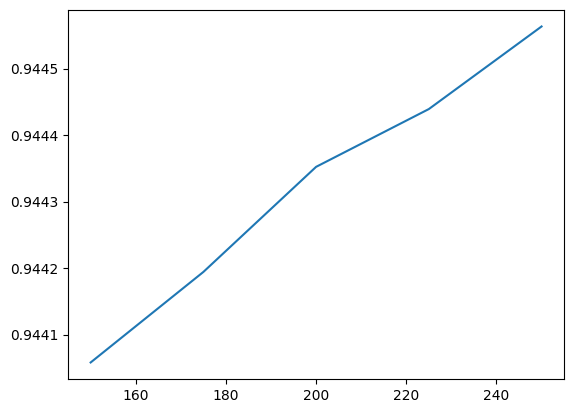

In [166]:
import matplotlib.pyplot as plt
plt.plot(list(150+25*i for i in range(0,5)), list(score))
plt.show()

In [167]:
rf_model = RandomForestClassifier(n_estimators=250, random_state=42, criterion='entropy', 
                                  max_features='sqrt', verbose=1, n_jobs=-1)
rf_model.fit(OH_train_X, train_y)
pd.DataFrame({'Feature': OH_train_X.columns, 'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 188 tasks      | elapsed:   27.4s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   35.8s finished


,Feature,Importance
3,TyreLife,0.101457
6,LapTime_Delta,0.099524
42,2023,0.095600
7,Cumulative_Degradation,0.085967
8,RaceProgress,0.084722
2,Stint,0.081728
5,LapTime (s),0.077701
1,LapNumber,0.074415
9,Position_Change,0.063518
4,Position,0.053929


In [ ]:
# we have seen that the importanca of the race variable is very low for all the values,
# so I'll try to remove this variable and build a variable with only pre-seanon or race
OH_train_X_rf = OH_train_X.copy()
race_var = list(categories[1])
pre_season_train = []
for val in train_X.Race:
    if val== 'Pre-Season Testing':
        pre_season_train.append(1)
    else:
        pre_season_train.append(0)
OH_train_X_rf['Pre-season'] = pre_season_train
OH_train_X_rf['Gran_Prix'] = list(1-np.array(pre_season_train))
OH_train_X_rf.drop(columns=race_var, inplace=True)

# for the validation set too
OH_valid_X_rf = OH_val_X.copy()
pre_season_valid = []
for val in val_X.Race:
    if val== 'Pre-Season Testing':
        pre_season_valid.append(1)
    else:
        pre_season_valid.append(0)
OH_valid_X_rf['Pre-season'] = pre_season_valid
OH_valid_X_rf['Gran_Prix'] = list(1-np.array(pre_season_valid))
OH_valid_X_rf.drop(columns=race_var, inplace=True)

,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,INTERMEDIATE,MEDIUM,HARD,SOFT,WET,2024,2023,2025,2022,Pre-season,Gran_Prix
id,,,,,,,,,,,,,,,,,,,,,
157757,0,3,1,3.0,11,94.500,-1.341,-10.570,0.052632,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
212674,0,46,2,25.0,10,102.939,0.344,-20.719,0.821429,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
208745,0,14,2,7.0,19,93.746,0.077,-17.333,0.250000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1
350823,0,36,3,19.0,13,107.800,23.846,-8.905,0.507042,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1
3349,0,3,1,3.0,13,101.173,-1.845,25.964,0.042857,-5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,1


In [168]:
score_norace = []
for i in range(0,5):
    rf_model_norace = RandomForestClassifier(n_estimators=175+25*i, random_state=42, criterion='entropy',
                                             max_features='sqrt', verbose=0, n_jobs=-1)
    rf_model_norace.fit(OH_train_X_rf, train_y)
    score_norace.append(roc_auc_score(val_y, rf_model_norace.predict_proba(OH_valid_X_rf)[:, 1]))


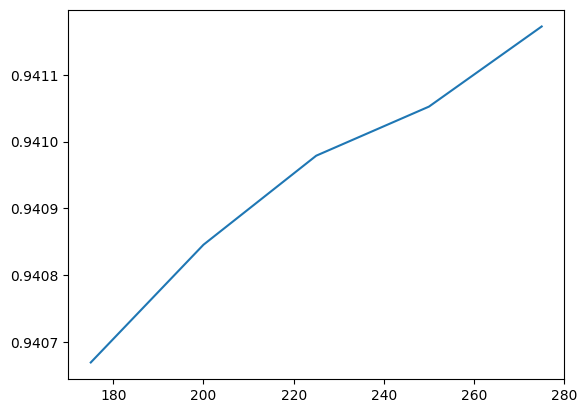

In [171]:
plt.plot(list(175+25*i for i in range(0,5)), list(score_norace))
plt.show()

In [172]:
rf_model_norace = RandomForestClassifier(n_estimators=275, random_state=42, criterion='entropy',
                                        max_features='sqrt', verbose=1, n_jobs=-1)
rf_model_norace.fit(OH_train_X_rf, train_y)
pd.DataFrame({'Feature': OH_train_X_rf.columns, 'Importance': rf_model_norace.feature_importances_}).sort_values(by='Importance', ascending=False)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 188 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 275 out of 275 | elapsed:   37.2s finished


,Feature,Importance
6,LapTime_Delta,0.113566
3,TyreLife,0.108722
16,2023,0.105580
7,Cumulative_Degradation,0.094992
5,LapTime (s),0.092646
2,Stint,0.091000
8,RaceProgress,0.084301
1,LapNumber,0.077994
9,Position_Change,0.064809
4,Position,0.057144


In [173]:
val_pred_rf = rf_model.predict(OH_val_X)
val_pred_rf_norace = rf_model_norace.predict(OH_valid_X_rf)
roc_auc_with_race = roc_auc_score(val_y, rf_model.predict_proba(OH_val_X)[:, 1])
roc_auc_without_race = roc_auc_score(val_y, rf_model_norace.predict_proba(OH_valid_X_rf)[:, 1])

[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.3s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:    1.7s
[Parallel(n_jobs=6)]: Done 250 out of 250 | elapsed:    2.2s finished
[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:    1.5s
[Parallel(n_jobs=6)]: Done 275 out of 275 | elapsed:    2.3s finished
[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.3s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:    1.7s
[Parallel(n_jobs=6)]: Done 250 out of 250 | elapsed:    2.3s finished
[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.3s
[Parallel(n_jobs=6)]: Done 188 tasks      |

In [174]:
print(f"ROC AUC with race variable: {roc_auc_with_race}")
print(f"ROC AUC without race variable: {roc_auc_without_race}")

ROC AUC with race variable: 0.9445632265615836
ROC AUC without race variable: 0.9411724236064662


The difference between using or not the race variable is very small, but at the same time we are reducing
the number of variables a lot, so we could take into account to not use this variable.

## Test set

### Preprocess and encoding the test set

In [180]:
test.Year = test.Year.astype(str)
test.drop(columns=['Driver'], inplace=True)

OH_test_var = pd.DataFrame(OH_encoder.transform(test[cat_vars]))
OH_test_var.index = test.index
num_var_test = test.drop(columns=cat_vars)
OH_test = pd.concat([num_var_test, OH_test_var], axis=1)
OH_test.columns = num_var_test.columns.tolist() + list(categories[0])+list(categories[1])+list(categories[2])

OH_test_norace = OH_test.copy()
pre_season_test = []
for val in test.Race:
    if val== 'Pre-Season Testing':
        pre_season_test.append(1)
    else:
        pre_season_test.append(0)
OH_test_norace['Pre-season'] = pre_season_test
OH_test_norace['Gran_Prix'] = list(1-np.array(pre_season_test))
OH_test_norace.drop(columns=race_var, inplace=True)

### test prediction

In [190]:
#rf_model.fit(pd.concat([OH_train_X,OH_val_X]), pd.concat([train_y,val_y]))
test_pred_rf = rf_model.predict_proba(OH_test)[:, 1]
sample_submission.PitNextLap = test_pred_rf
sample_submission.to_csv(path_or_buf='rf_prediction.csv')

[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.8s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:    3.3s
[Parallel(n_jobs=6)]: Done 250 out of 250 | elapsed:    4.2s finished


In [ ]:
rf_model_norace.fit(pd.concat([OH_train_X_rf, OH_valid_X_rf ]), pd.concat([train_y,val_y]))
test_pred_rf_norace = rf_model_norace.predict_proba(OH_test_norace)[:, 1]
sample_submission.PitNextLap = test_pred_rf_norace
sample_submission.to_csv(path_or_buf='rf_prediction_norace.csv')

[Parallel(n_jobs=6)]: Using backend ThreadingBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    0.8s
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:    3.6s
[Parallel(n_jobs=6)]: Done 275 out of 275 | elapsed:    4.9s finished
